In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
class Activation:
    def __init__(self, name: str):
        self.name = name

        self.functions = {
            'sigmoid': self.sigmoid,
            'tanh': np.tanh,
            'relu': self.relu,
            'linear': lambda x: x,
            'softmax': self.softmax,
            'binary_step': lambda x: np.where(x >= 0, 1, 0)
        }

        self.derivatives = {
            'sigmoid': lambda out: out * (1 - out),
            'tanh': lambda out: 1 - out**2,
            'relu': self.relu_derivative,
            'linear': lambda out: np.ones_like(out),
            'softmax': lambda out: np.ones_like(out),
            'binary_step': lambda out: np.zeros_like(out)
        }

        if name not in self.functions:
            raise ValueError(f"Activation '{name}' not defined")

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.input = x
        self.output = self.functions[self.name](x)
        return self.output

    def derivative(self) -> np.ndarray:
        return self.derivatives[self.name](self.output)

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        return grad_output * self.derivative()


    @staticmethod
    def sigmoid(x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def relu(x: np.ndarray) -> np.ndarray:
        return np.maximum(0, x)

    @staticmethod
    def softmax(x: np.ndarray) -> np.ndarray:
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

    def relu_derivative(self, out: np.ndarray) -> np.ndarray:
        return np.where(self.input > 0, 1, 0)

In [19]:
class Loss:
    def __init__(self, name: str):
        self.name = name

        self.functions = {
            'mse': lambda y_true, y_pred: np.mean((y_true - y_pred)**2),
            'cross_entropy': self.cross_entropy,
            'categorical_cross_entropy': self.categorical_cross_entropy,
        }

        self.derivatives = {
            'mse': lambda y_true, y_pred: 2 * (y_pred - y_true) / y_true.shape[0],
            'cross_entropy': self.cross_entropy_derivative,
            'categorical_cross_entropy': lambda y_true, y_pred: (y_pred - y_true) / y_true.shape[0]
        }

        if name not in self.functions:
            raise ValueError(f"Loss '{name}' not define.")

    def forward(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return self.functions[self.name](y_true, y_pred)

    def derivative(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        return self.derivatives[self.name](y_true, y_pred)

    @staticmethod
    def cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    @staticmethod
    def categorical_cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    @staticmethod
    def cross_entropy_derivative(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return (y_pred - y_true) / (y_true.shape[0] * y_pred * (1 - y_pred))


In [20]:
class ActivationLayer:
    def __init__(self, activation: str):
        self.activation = Activation(activation)
        self.output = None
        self.input = None


    def forward(self, inputs: np.ndarray) -> np.ndarray:
        self.input = inputs
        self.output = self.activation.forward(inputs)
        return self.output

    def backward(self, output_error: np.ndarray, learning_rate: float = None) -> np.ndarray:
        return output_error * self.activation.derivative()

In [21]:
class Layer:
    def __init__(self, num_neurons, num_inputs):
        self.num_neurons = num_neurons
        self.num_inputs = num_inputs

        self.weights = np.random.uniform(-1, 1, (num_neurons, num_inputs))
        self.bias = np.random.uniform(-1, 1, (1, num_neurons))

        self.input = None
        self.output = None

        self.m_w = np.zeros_like(self.weights)
        self.v_w = np.zeros_like(self.weights)
        self.m_b = np.zeros_like(self.bias)
        self.v_b = np.zeros_like(self.bias)
        self.t = 0

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        inputs = np.atleast_2d(inputs)
        self.input = inputs
        self.output = inputs @ self.weights.T + self.bias
        return self.output

    def backward(self, output_error: np.ndarray, learning_rate: float,
                 beta1: float = 0.9, beta2: float = 0.999, epsilon: float = 1e-8) -> np.ndarray:

        self.t += 1
        batch_size = self.input.shape[0]

        weight_gradient = (output_error.T @ self.input) / batch_size
        bias_gradient = output_error.mean(axis=0, keepdims=True)

        self.m_w = beta1 * self.m_w + (1 - beta1) * weight_gradient
        self.m_b = beta1 * self.m_b + (1 - beta1) * bias_gradient

        self.v_w = beta2 * self.v_w + (1 - beta2) * (weight_gradient ** 2)
        self.v_b = beta2 * self.v_b + (1 - beta2) * (bias_gradient ** 2)

        m_hat_w = self.m_w / (1 - beta1 ** self.t)
        v_hat_w = self.v_w / (1 - beta2 ** self.t)
        m_hat_b = self.m_b / (1 - beta1 ** self.t)
        v_hat_b = self.v_b / (1 - beta2 ** self.t)

        self.weights -= learning_rate * m_hat_w / (np.sqrt(v_hat_w) + epsilon)
        self.bias -= learning_rate * m_hat_b / (np.sqrt(v_hat_b) + epsilon)

        return output_error @ self.weights

In [42]:
class MLP:
    def __init__(self, layers: list, loss_name: str = "mse"):
        self.layers: list = layers
        self.loss = Loss(loss_name)

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        output = inputs
        for layer in self.layers:
            output = layer.forward(output)
        return output

    def backward(self, inputs: np.ndarray, targets: np.ndarray, learning_rate: float,
                 batch_size: int = 32) -> float:
                 epoch_loss = 0
                 num_batches = int(np.ceil(inputs.shape[0] / batch_size))

                 for batch_start in range(0, inputs.shape[0], batch_size):
                  batch_X = inputs[batch_start:batch_start + batch_size]
                  batch_y = targets[batch_start:batch_start + batch_size]
                  predictions = self.forward(batch_X)
                  error_gradient = self.loss.derivative(batch_y, predictions)

                  for layer in reversed(self.layers):
                    if isinstance(layer, Layer):
                      error_gradient = layer.backward(error_gradient, learning_rate)
                    else:
                      error_gradient = layer.backward(error_gradient)
                      epoch_loss += self.loss.forward(batch_y, predictions)

                 return epoch_loss / num_batches

    def train(self, inputs: np.ndarray, targets: np.ndarray, learning_rate: float = 0.01,
              epochs: int = 100, batch_size: int = 32, debug: bool = False) -> list[float]:
        loss_history = [] if debug else None
        for epoch in range(epochs):
            loss_value = self.backward(inputs, targets, learning_rate, batch_size)
            if debug:
                loss_history.append(loss_value)
            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss: {loss_value}")
        return loss_history

In [33]:
def plot_loss(loss_history, title):
    plt.figure(figsize=(6,4))
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.show()

def show_predictions(model, inputs, name):
    print(f"\n{name} predictions")

    for x in inputs:
        prediction = model.forward(np.array([x]))
        print(f"{x} -> {np.round(prediction)}")

def check_accuracy(model, inputs, targets):
    correct = 0

    for x, y in zip(inputs, targets):
        prediction = np.round(model.forward(np.array([x])))
        if (prediction == y).all():
            correct += 1

    accuracy = correct / len(inputs)

    print(f"Accuracy: {accuracy:.2f}")

    return accuracy

Epoch 0, Loss: 0.3727599592095968
Epoch 10, Loss: 0.15599512248688868
Epoch 20, Loss: 0.0779508394960826
Epoch 30, Loss: 0.06566598540253585
Epoch 40, Loss: 0.06618577807098518
Epoch 50, Loss: 0.0641766006729869
Epoch 60, Loss: 0.06278206693549666
Epoch 70, Loss: 0.06254660809458715
Epoch 80, Loss: 0.06252654511884612
Epoch 90, Loss: 0.06252157143049533


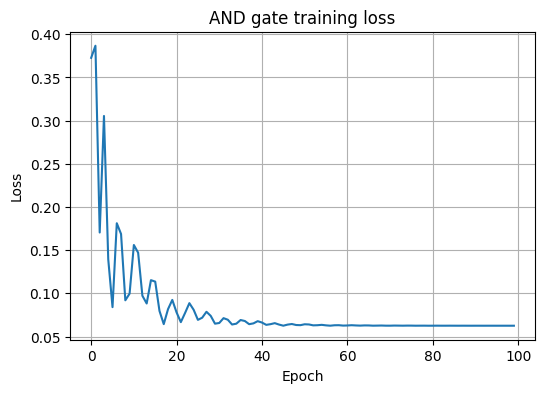


AND gate predictions
[0 0] -> [[-0.]]
[0 1] -> [[0.]]
[1 0] -> [[0.]]
[1 1] -> [[1.]]
Accuracy: 1.00


In [43]:
and_inputs = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

and_targets = np.array([
    [0],
    [0],
    [0],
    [1]
])

and_layers = [
    Layer(num_neurons=1, num_inputs=2),
    ActivationLayer("linear")
]

and_mlp = MLP(and_layers)
and_loss = and_mlp.train(and_inputs, and_targets, learning_rate=0.5, epochs=100, debug=True)

plot_loss(and_loss, "AND gate training loss")
show_predictions(and_mlp, and_inputs, "AND gate")
and_accuracy = check_accuracy(and_mlp, and_inputs, and_targets)

Epoch 0, Loss: 0.36529576690522414
Epoch 10, Loss: 0.15130541410554108
Epoch 20, Loss: 0.08185239680742255
Epoch 30, Loss: 0.06290849910123592
Epoch 40, Loss: 0.0681248978778236
Epoch 50, Loss: 0.06518773250370426
Epoch 60, Loss: 0.06276637235019877
Epoch 70, Loss: 0.0627581796886289
Epoch 80, Loss: 0.06265476027939551
Epoch 90, Loss: 0.06253469104698416


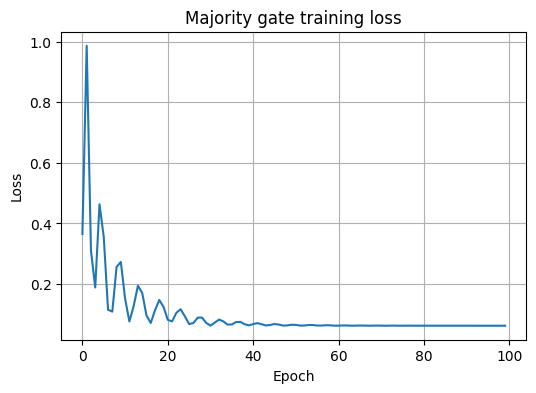


Majority gate predictions
[0 0 0] -> [[-0.]]
[0 0 1] -> [[0.]]
[0 1 0] -> [[0.]]
[0 1 1] -> [[1.]]
[1 0 0] -> [[0.]]
[1 0 1] -> [[1.]]
[1 1 0] -> [[1.]]
[1 1 1] -> [[1.]]
Accuracy: 1.00
Majority gate accuracy: 100.00%


In [44]:
majority_inputs = np.array([
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
])

majority_targets = np.array([
    [0],
    [0],
    [0],
    [1],
    [0],
    [1],
    [1],
    [1]
])
majority_layers = [
    Layer(num_neurons=1, num_inputs=3),
    ActivationLayer("linear")
]

majority_mlp = MLP(majority_layers)
majority_loss = majority_mlp.train(majority_inputs,majority_targets,learning_rate=0.5,epochs=100,debug=True)


plot_loss(majority_loss, "Majority gate training loss")
show_predictions(majority_mlp, majority_inputs, "Majority gate")

majority_accuracy = check_accuracy(majority_mlp, majority_inputs, majority_targets)
print(f"Majority gate accuracy: {majority_accuracy*100:.2f}%")

Epoch 0, Loss: 0.5431341638376744
Epoch 10, Loss: 0.48421590638329803
Epoch 20, Loss: 0.3931137084527584
Epoch 30, Loss: 0.1725425598924195
Epoch 40, Loss: 0.01744703201185374
Epoch 50, Loss: 0.00562427707361571
Epoch 60, Loss: 0.003065914072137821
Epoch 70, Loss: 0.0021915194271419597
Epoch 80, Loss: 0.0017649484857985805
Epoch 90, Loss: 0.0015043003584770949
Epoch 100, Loss: 0.0013276201831133728
Epoch 110, Loss: 0.001195791132858666
Epoch 120, Loss: 0.0010900154499373386
Epoch 130, Loss: 0.0010016351519345277
Epoch 140, Loss: 0.0009260094737539555
Epoch 150, Loss: 0.000860200974561319
Epoch 160, Loss: 0.0008022177544857546
Epoch 170, Loss: 0.0007506488715131607
Epoch 180, Loss: 0.0007044458000093883
Epoch 190, Loss: 0.0006627984130006827
Epoch 200, Loss: 0.0006250639436581042
Epoch 210, Loss: 0.0005907223079424598
Epoch 220, Loss: 0.0005593459128800948
Epoch 230, Loss: 0.0005305785402638421
Epoch 240, Loss: 0.00050412017609098
Epoch 250, Loss: 0.0004797158063593707
Epoch 260, Loss: 

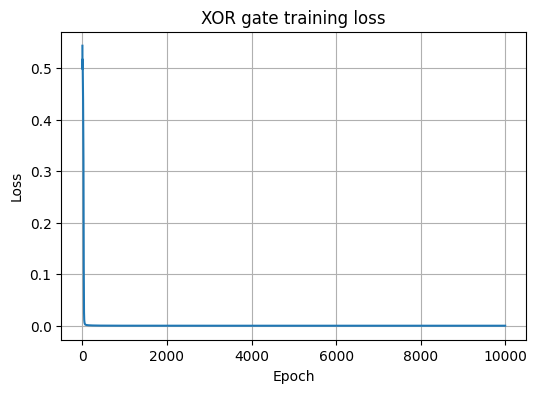


XOR gate predictions
[0 0] -> [[0.]]
[0 1] -> [[1.]]
[1 0] -> [[1.]]
[1 1] -> [[0.]]
Accuracy: 1.00
XOR gate accuracy: 100.00%


In [46]:

xor_inputs = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

xor_targets = np.array([
    [0],
    [1],
    [1],
    [0]
])

xor_layers = [
    Layer(num_neurons=2, num_inputs=2),
    ActivationLayer("sigmoid"),
    Layer(num_neurons=1, num_inputs=2),
    ActivationLayer("sigmoid")
]

xor_mlp = MLP(xor_layers)


xor_loss = xor_mlp.train(xor_inputs,xor_targets,learning_rate=0.3,epochs=10000, debug=True)

plot_loss(xor_loss, "XOR gate training loss")
show_predictions(xor_mlp, xor_inputs, "XOR gate")

xor_accuracy = check_accuracy(xor_mlp, xor_inputs, xor_targets)
print(f"XOR gate accuracy: {xor_accuracy*100:.2f}%")

Epoch 0, Loss: 2.8924590434853923
Epoch 10, Loss: 3.7837799881681275e-06
Epoch 20, Loss: 3.0243862724581957e-06
Epoch 30, Loss: 2.3861658038885463e-06
Epoch 40, Loss: 1.8995406275225629e-06
Epoch 50, Loss: 1.547848271103997e-06
Epoch 60, Loss: 1.2771818960124613e-06
Epoch 70, Loss: 1.0669826730337268e-06
Epoch 80, Loss: 9.016489777632914e-07
Epoch 90, Loss: 7.698211645682864e-07
Epoch 100, Loss: 6.633048019852886e-07
Epoch 110, Loss: 5.76164424147021e-07
Epoch 120, Loss: 5.040579904317085e-07
Epoch 130, Loss: 4.437698553126764e-07
Epoch 140, Loss: 3.9288736719287845e-07
Epoch 150, Loss: 3.4957678669863677e-07
Epoch 160, Loss: 3.1242690987347066e-07
Epoch 170, Loss: 2.8033881827006177e-07
Epoch 180, Loss: 2.524472441732867e-07
Epoch 190, Loss: 2.2806380822539583e-07


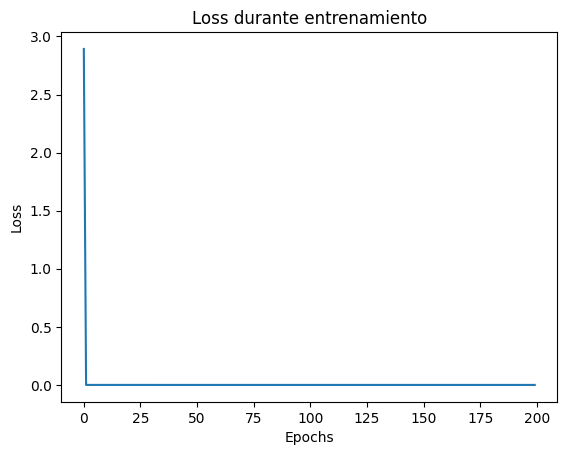

Accuracy: 100.00%


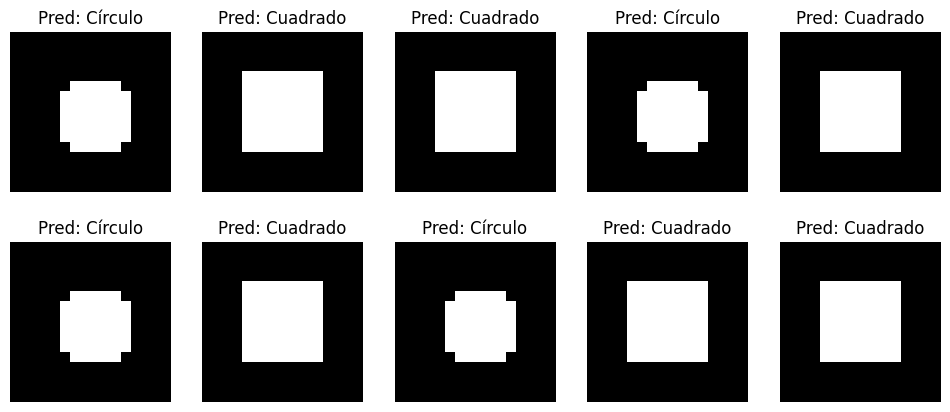

Accuracy en datos nuevos: 100.00%


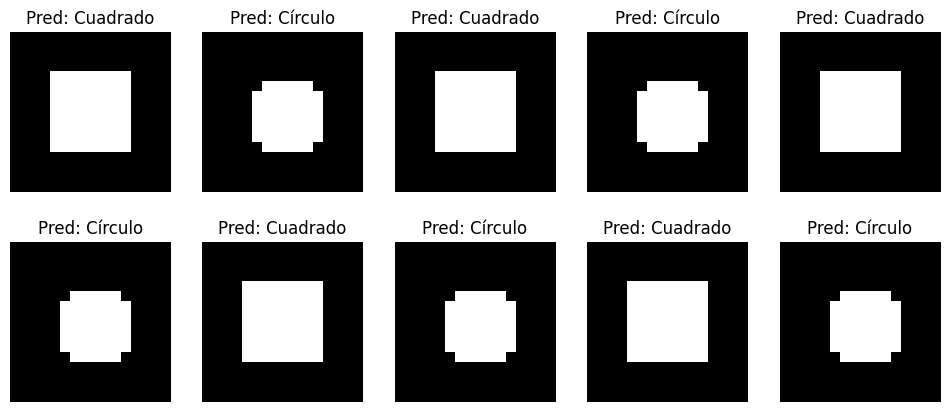

In [48]:
from skimage.draw import disk, rectangle

def generate_shapes_simplified(num_samples=100, img_size=16, new_data=False):
    X = np.zeros((num_samples, img_size*img_size))
    y = np.zeros((num_samples, 2))

    for i in range(num_samples):
        img = np.zeros((img_size, img_size))

        if i % 2 == 0:
            start = img_size // 4
            extent = img_size // 2
            rr, cc = rectangle(start=(start, start), end=(start+extent-1, start+extent-1))
            img[rr, cc] = 1
            y[i, 0] = 1
        else:
            center = img_size // 2
            radius = img_size // 4
            rr, cc = disk((center, center), radius)
            img[rr, cc] = 1
            y[i, 1] = 1

        X[i] = img.flatten()

    return X, y

X_train, y_train = generate_shapes_simplified(200)
perm = np.random.permutation(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]
X_train = X_train.astype(np.float32)

layers = [
    Layer(num_neurons=32, num_inputs=X_train.shape[1]),
    Activation("relu"),
    Layer(num_neurons=16, num_inputs=32),
    Activation("relu"),
    Layer(num_neurons=2, num_inputs=16),
    Activation("softmax")
]

mlp = MLP(layers, loss_name="categorical_cross_entropy")

loss_history = mlp.train(
    X_train, y_train,
    learning_rate=0.01,
    epochs=200,
    batch_size=16,
    debug=True
)

plt.plot(loss_history)
plt.title("Loss durante entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

def test_model(X, y, mlp):
    preds = mlp.forward(X)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = np.argmax(y, axis=1)
    accuracy = np.mean(pred_labels == true_labels)
    print(f"Accuracy: {accuracy*100:.2f}%")
    return pred_labels

pred_labels = test_model(X_train, y_train, mlp)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i, ax in enumerate(axes.flatten()):
    img = X_train[i].reshape(16,16)
    label = "Cuadrado" if pred_labels[i]==0 else "Círculo"
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Pred: {label}")
    ax.axis("off")
plt.show()

X_test, y_test = generate_shapes_simplified(20, new_data=True)
X_test = X_test.astype(np.float32)
pred_test = mlp.forward(X_test)
pred_labels_test = np.argmax(pred_test, axis=1)
true_labels_test = np.argmax(y_test, axis=1)
accuracy_test = np.mean(pred_labels_test == true_labels_test)
print(f"Accuracy en datos nuevos: {accuracy_test*100:.2f}%")

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i, ax in enumerate(axes.flatten()):
    img = X_test[i].reshape(16,16)
    label = "Cuadrado" if pred_labels_test[i]==0 else "Círculo"
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Pred: {label}")
    ax.axis("off")
plt.show()